In [1]:
import os
from pathlib import Path
os.chdir(path = Path(r"C:\Users\apaks\projects\YT-RAG"))

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Tuple, List, Literal
from src.yt_rag.components.data_loader import DataLoader
from src.yt_rag.components.embedding import EmbeddingManager
from src.yt_rag.components.vectorstore import FaissVectorStore
import numpy as np
from src.yt_rag.components.search import RAGSearch

c:\Users\apaks\projects\YT-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class RAGState(TypedDict):

    video_url: Annotated[str, "the youtube video url"]
    video_id: Annotated[str, "video id extracted from url"]
    query: Annotated[str, "user's query"]
    video_data: Annotated[List[dict[str, str]], "fetch video data using api and preprocess"]
    chunks: Annotated[list[dict[str, str]], "chunks created after semantic chunksing."]     # in the form of a dict with keys (text, start time and end time)
    embeddings: Annotated[np.array, "embeddings for the chunks"]
    vector_store: Annotated[bool, "True if vector store exists, False otherwise"]
    context: Annotated[str, "most relevant context fetched using rag search"]
    answer: Annotated[str, "Answer generated by llm"]
    time_stamps: Annotated[List[Tuple], "Timestamps of top k results"]

In [4]:
def fetch_video_id(state: RAGState) -> RAGState:
    loader = DataLoader(url = state['video_url'])
    video_id = loader.video_id

    return {"video_id": video_id}

def check_vector_store(state: RAGState) -> Literal["search_vector_store", "fetch_video_data"]:
    persist_dir = "faiss_store"
    existing_vector_stores = os.listdir(persist_dir)
    if state['video_id'] in existing_vector_stores:
        return "search_vector_store"
    else:
        return "fetch_video_data"

def fetch_video_data(state: RAGState):
    loader = DataLoader(url = state['video_url'])
    video_data = loader.fetch_video_data()
    return {'video_data': video_data}

def create_chunks(state: RAGState):
    loader = DataLoader(url = state['video_url'])
    chunks = loader.create_semantic_chunks(video_data= state['video_data'])
    return {"chunks": chunks}

def generate_embeddings(state: RAGState):
    embedding_manager = EmbeddingManager()
    embeddings = embedding_manager.generate_embeddings(chunks = state['chunks'])
    return {"embeddings": embeddings}

def build_vector_store(state: RAGState):
    faiss_store = FaissVectorStore(video_id=state['video_id'])
    faiss_store.add_embeddings(embeddings= state['embeddings'])
    return {"vector_store": True}

def search_vector_store(state: RAGState):
    rag_search = RAGSearch(url = state['video_url'])
    context = rag_search.search(query = state['query'])
    return {'context': context}

def generate_response(state: RAGSearch):
    rag = RAGSearch(url = state['video_url'], video_id = state['video_id'])
    response = rag.generate_response(context = state['context'], query = state['query'])
    time_stamps = rag.get_video_timestamps()
    return {"answer": response, "time_stamps": time_stamps}


In [5]:
graph = StateGraph(RAGState)

graph.add_node("fetch_video_id", fetch_video_id)
graph.add_node("fetch_video_data", fetch_video_data)
graph.add_node("create_chunks", create_chunks)
graph.add_node("generate_embeddings", generate_embeddings)
graph.add_node("build_vector_store", build_vector_store)
graph.add_node("search_vector_store", search_vector_store)
graph.add_node("generate_response", generate_response)

graph.add_edge(START, "fetch_video_id")
graph.add_conditional_edges(
    "fetch_video_id", 
    check_vector_store,
    {
        "search_vector_store": "search_vector_store",
        "fetch_video_data": "fetch_video_data"
    }
)
graph.add_edge("fetch_video_data", "create_chunks")
graph.add_edge("create_chunks", "generate_embeddings")
graph.add_edge("generate_embeddings", "build_vector_store")
graph.add_edge("build_vector_store", "search_vector_store")

graph.add_edge("search_vector_store", "generate_response")
graph.add_edge("generate_response", END)

rag_workflow = graph.compile()



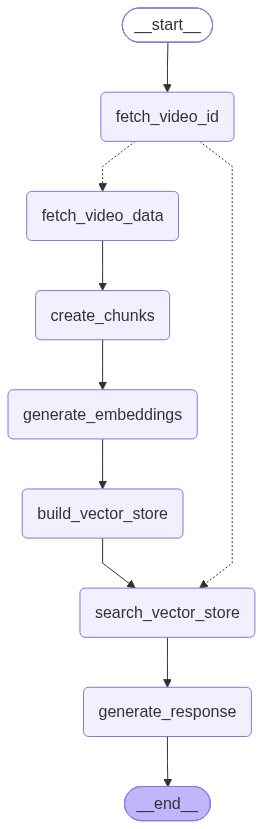

In [6]:
from IPython.display import Image
Image(rag_workflow.get_graph().draw_mermaid_png())

In [13]:
initial_state = {
    "video_url": "https://www.youtube.com/watch?v=ywd-Ve8a8Tc",
    "query": """What is the definition of psycho-history?"""
}

result = rag_workflow.invoke(initial_state)
result['answer']

'Final Answer: Psycho-history is the idea of taking human history and looking at it from a macro perspective, identifying patterns that emerge over tens of thousands of years, which can then be mathematically modeled to extrapolate these patterns into the future and predict how events will unfold.'